In [38]:
# 1. IMPORTAR LIBRERÍAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [10]:
# 2. CARGAR DATASET
df = pd.read_csv("CO2_Emissions_Canada.csv")


In [39]:
# 3. VISTA INICIAL DEL DATASET
print("Primeras filas del dataset:")
display(df.head())

print("\nDimensiones del dataset:")
print(df.shape)

print("\nNombres de columnas:")
print(df.columns.tolist())

Primeras filas del dataset:


,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244



Dimensiones del dataset:
(6282, 12)

Nombres de columnas:
['Make', 'Model', 'Vehicle Class', 'Engine Size(L)', 'Cylinders', 'Transmission', 'Fuel Type', 'Fuel Consumption City (L/100 km)', 'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)', 'Fuel Consumption Comb (mpg)', 'CO2 Emissions(g/km)']


In [40]:
# 4. INFORMACIÓN GENERAL
print("Información general del dataset:")
df.info()

print("\nDescripción estadística de variables numéricas:")
display(df.describe())

Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
Index: 6282 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              6282 non-null   object 
 1   Model                             6282 non-null   object 
 2   Vehicle Class                     6282 non-null   object 
 3   Engine Size(L)                    6282 non-null   float64
 4   Cylinders                         6282 non-null   int64  
 5   Transmission                      6282 non-null   object 
 6   Fuel Type                         6282 non-null   object 
 7   Fuel Consumption City (L/100 km)  6282 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   6282 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  6282 non-null   float64
 10  Fuel Consumption Comb (mpg)       6282 non-null   int64  
 11  CO2 Emissions(g/km)               6282 no

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
count,6282.000000,6282.000000,6282.000000,6282.000000,6282.000000,6282.000000,6282.000000
mean,3.161812,5.618911,12.610220,9.070583,11.017876,27.411016,251.157752
std,1.365201,1.846250,3.553066,2.278884,2.946876,7.245318,59.290426
min,0.900000,3.000000,4.200000,4.000000,4.100000,11.000000,96.000000
25%,2.000000,4.000000,10.100000,7.500000,8.900000,22.000000,208.000000
50%,3.000000,6.000000,12.100000,8.700000,10.600000,27.000000,246.000000
75%,3.700000,6.000000,14.700000,10.300000,12.700000,32.000000,289.000000
max,8.400000,16.000000,30.600000,20.600000,26.100000,69.000000,522.000000


In [ ]:
# 5. LIMPIEZA DE DATOS
print("Valores nulos por columna antes de limpiar:")
print(df.isnull().sum())

print("\nNúmero de filas duplicadas antes de limpiar:")
print(df.duplicated().sum())

# Eliminar duplicados
df = df.drop_duplicates()

# Eliminar nulos
df = df.dropna()

print("\nDimensiones después de la limpieza:")
print(df.shape)

print("\nValores nulos por columna después de limpiar:")
print(df.isnull().sum())

Valores nulos por columna antes de limpiar:
Make                                0
Model                               0
Vehicle Class                       0
Engine Size(L)                      0
Cylinders                           0
Transmission                        0
Fuel Type                           0
Fuel Consumption City (L/100 km)    0
Fuel Consumption Hwy (L/100 km)     0
Fuel Consumption Comb (L/100 km)    0
Fuel Consumption Comb (mpg)         0
CO2 Emissions(g/km)                 0
dtype: int64

Número de filas duplicadas antes de limpiar:
0

Dimensiones después de la limpieza:
(6282, 12)

Valores nulos por columna después de limpiar:
Make                                0
Model                               0
Vehicle Class                       0
Engine Size(L)                      0
Cylinders                           0
Transmission                        0
Fuel Type                           0
Fuel Consumption City (L/100 km)    0
Fuel Consumption Hwy (L/100 km)     0
Fu

In [ ]:
# 6. SELECCIÓN DE VARIABLES
features = [
    "Vehicle Class",
    "Engine Size(L)",
    "Cylinders",
    "Transmission",
    "Fuel Type",
    "Fuel Consumption City (L/100 km)",
    "Fuel Consumption Hwy (L/100 km)",
    "Fuel Consumption Comb (L/100 km)",
    "Fuel Consumption Comb (mpg)"
]

target = "CO2 Emissions(g/km)"

X = df[features]
y = df[target]

print("Variables de entrada seleccionadas:")
print(features)

print("\nVariable objetivo:")
print(target)

Variables de entrada seleccionadas:
['Vehicle Class', 'Engine Size(L)', 'Cylinders', 'Transmission', 'Fuel Type', 'Fuel Consumption City (L/100 km)', 'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)', 'Fuel Consumption Comb (mpg)']

Variable objetivo:
CO2 Emissions(g/km)


In [ ]:
# 7. IDENTIFICAR VARIABLES NUMÉRICAS Y CATEGÓRICAS
num_features = [
    "Engine Size(L)",
    "Cylinders",
    "Fuel Consumption City (L/100 km)",
    "Fuel Consumption Hwy (L/100 km)",
    "Fuel Consumption Comb (L/100 km)",
    "Fuel Consumption Comb (mpg)"
]

cat_features = [
    "Vehicle Class",
    "Transmission",
    "Fuel Type"
]

print("Variables numéricas:")
print(num_features)

print("\nVariables categóricas:")
print(cat_features)

Variables numéricas:
['Engine Size(L)', 'Cylinders', 'Fuel Consumption City (L/100 km)', 'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)', 'Fuel Consumption Comb (mpg)']

Variables categóricas:
['Vehicle Class', 'Transmission', 'Fuel Type']


In [44]:
# 8. PREPROCESADO
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
    ]
)

print("Preprocesado definido correctamente.")

Preprocesado definido correctamente.


In [45]:
# 9. DIVISIÓN TRAIN / TEST
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Dimensiones de X_train:", X_train.shape)
print("Dimensiones de X_test:", X_test.shape)
print("Dimensiones de y_train:", y_train.shape)
print("Dimensiones de y_test:", y_test.shape)

Dimensiones de X_train: (5025, 9)
Dimensiones de X_test: (1257, 9)
Dimensiones de y_train: (5025,)
Dimensiones de y_test: (1257,)


In [46]:
# 10. MODELO 1: LINEAR REGRESSION
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

print("Modelo Linear Regression entrenado correctamente.")

Modelo Linear Regression entrenado correctamente.


In [47]:
# 11. MODELO 2: RANDOM FOREST REGRESSOR
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

print("Modelo Random Forest Regressor entrenado correctamente.")

Modelo Random Forest Regressor entrenado correctamente.


In [48]:
# 12. MODELO 3: DECISION TREE REGRESSOR
dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])

dt_pipeline.fit(X_train, y_train)

print("Modelo Decision Tree Regressor entrenado correctamente.")

Modelo Decision Tree Regressor entrenado correctamente.


In [49]:
# 13. PREDICCIONES
y_pred_lr = lr_pipeline.predict(X_test)
y_pred_rf = rf_pipeline.predict(X_test)
y_pred_dt = dt_pipeline.predict(X_test)

In [50]:
# 14. EVALUACIÓN M1: LINEAR REGRESSION
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("- Linear Regression -")
print("MAE:", mae_lr)
print("MSE:", mse_lr)
print("RMSE:", rmse_lr)
print("R2:", r2_lr)

- Linear Regression -
MAE: 3.2377370678558597
MSE: 31.38151689127895
RMSE: 5.601920821582446
R2: 0.99130397986091


In [51]:
# 15. EVALUACIÓN M2: RANDOM FOREST
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("- Random Forest -")
print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)
print("R2:", r2_rf)

- Random Forest -
MAE: 2.0285587984013174
MSE: 13.98314945464145
RMSE: 3.7394049599690926
R2: 0.9961251793631665


In [52]:
# 16. EVALUACIÓN M3: DECISION TREE
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("- Decision Tree -")
print("MAE:", mae_dt)
print("MSE:", mse_dt)
print("RMSE:", rmse_dt)
print("R2:", r2_dt)

- Decision Tree -
MAE: 2.0530154941849452
MSE: 16.82449312872855
RMSE: 4.101767073924183
R2: 0.9953378247589407


In [53]:
# 17. COMPARACIÓN DE MODELOS
results = pd.DataFrame({
    "Modelo": ["Linear Regression", "Random Forest", "Decision Tree"],
    "MAE": [mae_lr, mae_rf, mae_dt],
    "MSE": [mse_lr, mse_rf, mse_dt],
    "RMSE": [rmse_lr, rmse_rf, rmse_dt],
    "R2": [r2_lr, r2_rf, r2_dt]
})

display(results.sort_values(by="R2", ascending=False))

,Modelo,MAE,MSE,RMSE,R2
1,Random Forest,2.028559,13.983149,3.739405,0.996125
2,Decision Tree,2.053015,16.824493,4.101767,0.995338
0,Linear Regression,3.237737,31.381517,5.601921,0.991304


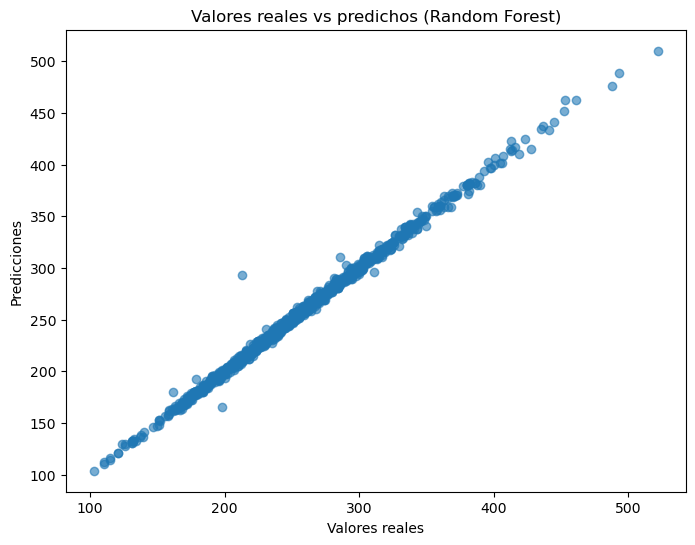

In [54]:
# 18. GRÁFICA VALORES REALES VS PREDICHOS (RANDOM FOREST)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.6)
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Valores reales vs predichos (Random Forest)")
plt.show()

In [55]:
# 19. OPTIMIZACIÓN DEL RANDOM FOREST
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Mejores parámetros encontrados:")
print(grid_search.best_params_)

Mejores parámetros encontrados:
{'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 200}


In [56]:
# 20. EVALUAR MODELO OPTIMIZADO
best_rf = grid_search.best_estimator_

y_pred_best = best_rf.predict(X_test)

mae_best = mean_absolute_error(y_test, y_pred_best)
mse_best = mean_squared_error(y_test, y_pred_best)
rmse_best = np.sqrt(mse_best)
r2_best = r2_score(y_test, y_pred_best)

print("=== Random Forest Optimizado ===")
print("MAE:", mae_best)
print("MSE:", mse_best)
print("RMSE:", rmse_best)
print("R2:", r2_best)

=== Random Forest Optimizado ===
MAE: 2.191236034475195
MSE: 14.549616120481572
RMSE: 3.814395905052538
R2: 0.9959682078072237


In [57]:
# 21. SELECCIÓN DEL MEJOR MODELO
print("Resultados Random Forest original:")
print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)
print("R2:", r2_rf)

print("\nResultados Random Forest optimizado:")
print("MAE:", mae_best)
print("MSE:", mse_best)
print("RMSE:", rmse_best)
print("R2:", r2_best)

if (mae_rf <= mae_best) and (mse_rf <= mse_best) and (rmse_rf <= rmse_best) and (r2_rf >= r2_best):
    final_model = rf_pipeline
    print("\nSe mantiene el Random Forest original como modelo final.")
else:
    final_model = best_rf
    print("\nSe selecciona el Random Forest optimizado como modelo final.")

Resultados Random Forest original:
MAE: 2.0285587984013174
MSE: 13.98314945464145
RMSE: 3.7394049599690926
R2: 0.9961251793631665

Resultados Random Forest optimizado:
MAE: 2.191236034475195
MSE: 14.549616120481572
RMSE: 3.814395905052538
R2: 0.9959682078072237

Se mantiene el Random Forest original como modelo final.


In [58]:
# 22. GUARDAR MODELO FINAL
joblib.dump(final_model, "modelo_co2.pkl")
print("Modelo final guardado correctamente como modelo_co2.pkl")

Modelo final guardado correctamente como modelo_co2.pkl
